<a href="https://colab.research.google.com/github/billalsohail/ML4MC/blob/main/Calum_MBTR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TEMPLATE FILE 
* Run the first cell to install all dependencies, download all data, and process all molecules into needed lists
* **SAVE A COPY TO GITHUB WITH A DIFFERENT NAME OR THIS WILL BE OVERWRITTEN**

In [142]:
# RUN THIS CELL 

! pip install dscribe  # Downloads needed modules
! pip install ase

# -------------------------------------------------------

import io
from datetime import datetime
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import requests
from ase.io import read
from sklearn.model_selection import train_test_split

def download_published_data():
  """Downloads and unzips data folder.
  """


  start = datetime.now()
  print(start)
  r = requests.get('https://people.bath.ac.uk/crh53/m1507656.zip')
  zipped = zipfile.ZipFile(io.BytesIO(r.content))
  zipped.extractall('')
  finish = datetime.now()
  print(finish)
  print(finish - start)

def xyz_str_to_atoms(xyz_str):
  """
  Convert a xyz file to an ASE atoms object via in-memory file (StringIO).
  """
  f = io.StringIO()
  f.write(xyz_str)
  f.seek(0)
  atoms = read(f, format="xyz")
  return atoms

# -------------------------------------------------------

print('Downloading data...')
download_published_data()  # downloads needed data
% cd m1507656

from helpers import get_level  # needs to go here as wont have been downloaded earlier in

print('Loading data...')
df = pd.read_json('df_5k.json', orient='split')

print('Generating `ase.Atoms` objects...')
df['atoms'] = df['xyz_pbe_relaxed'].apply(xyz_str_to_atoms)

print('Extracting HOMO, LUMO, BANDGAP from data...')
df['HOMO'] = df.apply(lambda row: get_level(row, level_type='HOMO', subset='GOWO_at_PBE0_cbs'), axis=1)
df['LUMO'] = df.apply(lambda row: get_level(row, level_type='LUMO', subset='GOWO_at_PBE0_cbs'), axis=1)
df['BG'] = df['LUMO'] - df['HOMO']
print('~ 2300 molecules do not have LUMO energy levels for this or any other `GOWO` level of theory.')

print('Splitting data set...')
train, test = train_test_split(df, test_size=0.2, random_state=20210817)
train_atoms, test_atoms = train['atoms'].to_list(), test['atoms'].to_list()

print('Data Processing Complete')
print('#', '-'*119)

2021-08-18 13:03:06.122434
2021-08-18 13:03:35.771557
0:00:29.649123
/content/m1507656/m1507656/m1507656
Loading data...
Generating `ase.Atoms` objects...
Extracting HOMO, LUMO, BANDGAP from data...
err FOVWES
err FOWGIH
err FOYJUZ
err FUNBUL
err FUPZAR
err FUXFAG
err GANSAQ
err GAQCEI
err NUFRUB
err GEPHEO
err GERGOB
err GETBUD
err GEVDAN
err GEYQAC
err GIDQAN
err GIMPUO
err GISBOA
err NUNJAH
err NUNJEL
err NUNKEM
err GODBUW
err NUQCIM
err WEBWUV
err GUCLIA
err GUMBEV
err HACGAT
err HADSEM
err HANBEF
err HANNEP
err LUXPAW
err HAVSIH
err HAWTEF
err HAXWAG
err HAZFNO
err HEHQIW
err HEJGOS
err HELCEG
err HEMLIU
err HEQMOG
err HERKEV
err HESKOF01
err HEVNAX
err HEVNIF
err HEWJIE
err OBOYOV
err HIFYAY
err HIJCEI
err HINREB
err HINTAZ
err WUJHOY
err HIVCOF
err HIXLOP
err WULZIM
err HMNCXC01
err HMSPYR
err HMTCSP10
err HOFJOB
err HOHGER
err HOHLAR
err HOJVUX
err HOKZEN
err HOQHUQ
err HORNUY
err OCAYUN
err HUHJUQ
err HUXKOB
err IFEFII
err IFOQIE
err LUZKEX
err IJEDAC
err IJENIU
err IJIWIH
err

## Helpful variables
>* Needed if you need to list all elements included in your train and testing datasets

In [143]:
atomic_numbers = df['atoms'].apply(lambda x: x.numbers)
unique_atomic_numbers = set([a for b in atomic_numbers for a in b])
max_num_atoms = atomic_numbers.apply(len).max()

print(unique_atomic_numbers)
print(max_num_atoms)

{1, 34, 35, 33, 5, 6, 7, 8, 9, 3, 14, 15, 16, 17, 53}
100


## `MBTR` Generation
* Going to try the `k2` and `k3` separately for the moment to see how that turns out
* Rough testing indicates `k2` is more reliable feature (also faster to calculate and produces smaller feature vector making resultant model training and assessment much quicker)
* Do a quick `t-SNE` visualisation on a subsample

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from dscribe.descriptors import MBTR

In [145]:
n = 30

feature_calc = MBTR(
    species=unique_atomic_numbers,
    k2={
        "geometry": {"function": "inverse_distance"},
        "grid": {"min": 0, "max": 1, "n": n, "sigma": 0.1},
        "weighting": {"function": "exp", "scale": 0.5, "threshold": 1e-3},
    },
    periodic=False,
    normalization="l2_each",
)

In [146]:
mol = df['atoms'].iloc[0]
out = feature_calc.create(mol, n_jobs=-1)

print(len(mol), n, '-->', out.shape)

30 30 --> (3600,)


In [147]:
print('Generating features...')
X_train, X_test = (np.vstack([feature_calc.create(a) for a in d]) for d in (train_atoms, test_atoms))
print('Features generated.')

Generating features...
Features generated.


In [148]:
level = 'HOMO'
y_train, y_test = (d[level].values for d in (train, test))

In [ ]:
reducer = TSNE()
out = reducer.fit_transform(X_train)

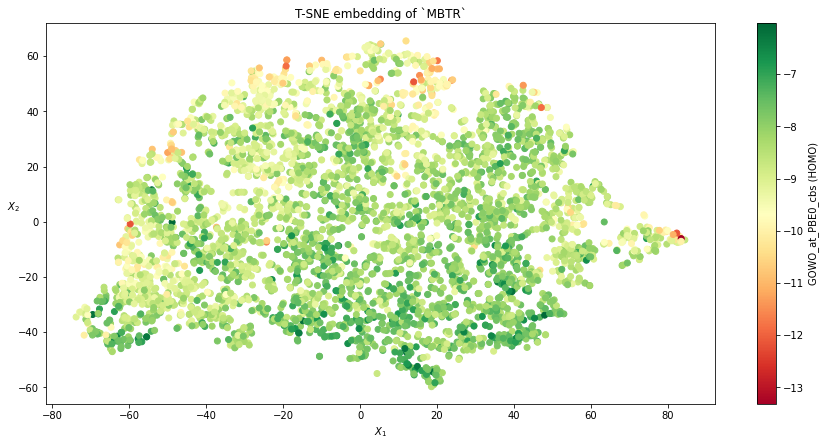

In [137]:
plt.figure(figsize=(15,7))
plt.title('T-SNE embedding of `MBTR`')
p = plt.scatter(out[:, 0], out[:, 1], c=y_train, cmap='RdYlGn')
plt.colorbar(p, cmap='RdYlGn', label='GOWO_at_PBE0_cbs (HOMO)')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$', rotation=0)
plt.show()

* Seems that there is some structure to the `t-SNE` projection with low energy levels occupying the periphery (although that could just be sampling bias with not many low energy molecules...)
* Does build confidence that the features contain a reasonable mapping however between feature space and target values

___
## KernelRidge Prediction

In [103]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

In [138]:
X_train.shape

(4191, 3600)

In [141]:
# iterate through different alpha values and generate train test curves for them

alpha_values = np.logspace(-3, 3, 7)
sizes = [10, 100, 1000, 2000, 3000]
m_entries = np.arange(len(X_train))
scores = {'train': [], 'test': []}

for alpha in alpha_values:
  print(alpha)
  for db_size in sizes:
    print(db_size)
    tr_samples = np.random.choice(m_entries, db_size, replace=False)
    cv_samples = np.delete(m_entries, tr_samples)
    X_tr, X_cv, y_tr, y_cv = X_train[tr_samples], X_train[cv_samples], y_train[tr_samples], y_train[cv_samples]

    model = KernelRidge(kernel='rbf', alpha=alpha)
    model.fit(X_tr, y_tr)
    tr_pred = model.predict(X_tr)
    cv_pred = model.predict(X_cv)
    
    scores['train'].append(mean_squared_error(y_tr, tr_pred))
    scores['train'].append(mean_squared_error(y_cv, cv_pred))

0.001
10
100
1000
2000
3000
0.01
10
100
1000
2000
3000
0.1
10
100
1000
2000
3000
1.0
10
100
1000
2000
3000
10.0
10
100
1000
2000
3000
100.0
10
100
1000
2000
3000
1000.0
10
100
1000
2000
3000


In [105]:
# split the training data again intor training and cross validation sets
X_tr, X_cv, y_tr, y_cv = train_test_split(X_train, y_train, test_size=0.2, random_state=1)

In [106]:
model = KernelRidge(kernel='rbf')
parameters = {'alpha': }
grid = GridSearchCV(model, param_grid=parameters, scoring='neg_mean_absolute_error', n_jobs=-1, cv=3, verbose=1)

In [107]:
grid.fit(X_train, y_train)

Fitting 3 folds for each of 7 candidates, totalling 21 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  21 out of  21 | elapsed:   49.9s finished
/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_ridge.py:188: LinAlgWarning: Ill-conditioned matrix (rcond=4.67352e-08): result may not be accurate.
  overwrite_a=False)


GridSearchCV(cv=3, error_score=nan,
             estimator=KernelRidge(alpha=1, coef0=1, degree=3, gamma=None,
                                   kernel='rbf', kernel_params=None),
             iid='deprecated', n_jobs=-1,
             param_grid={'alpha': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03])},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring='neg_mean_absolute_error', verbose=1)

In [108]:
estimator = grid.best_estimator_
print(F'Optimal alpha value from range is : {estimator.alpha}')

Optimal alpha value from range is : 0.001


In [109]:
estimator.fit(X_tr, y_tr)

KernelRidge(alpha=0.001, coef0=1, degree=3, gamma=None, kernel='rbf',
            kernel_params=None)

In [110]:
y_pred_tr = estimator.predict(X_tr)
y_pred_cv = estimator.predict(X_cv)

In [111]:
for s, pred, ref in zip(('train', 'cv'), (y_pred_tr, y_pred_cv), (y_tr, y_cv)):
  mse = mean_squared_error(ref, pred)
  r2 = r2_score(ref, pred)

  print(F'{s} : mse={mse:.3f}, r2={r2:.3f}')

train : mse=0.234, r2=0.660
cv : mse=0.228, r2=0.645


In [112]:
dummy = DummyRegressor()
dummy.fit(X_tr, y_tr)

for s, ref_x, ref_y in zip(('train', 'cv'), (X_tr, X_cv), (y_tr, y_cv)):
  pred = dummy.predict(ref_x)
  mse = mean_squared_error(ref_y, pred)
  r2 = r2_score(ref_y, pred)

  print(F'{s} : mse={mse:.3f}, r2={r2:.3f}')

train : mse=0.688, r2=0.000
cv : mse=0.643, r2=-0.002


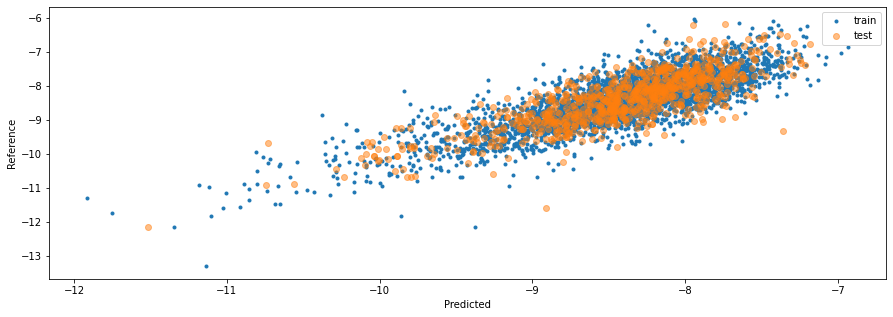

In [116]:
plt.figure(figsize=(15, 5))
plt.plot(y_pred_tr, y_tr, '.', alpha=1, label='train')
plt.plot(y_pred_cv, y_cv, 'o', alpha=0.5, label='test')
plt.xlabel('Predicted')
plt.ylabel('Reference')
plt.legend()
plt.show()

* Can see model has significnatly overfitted to the data